# Pooling Layer Implementation and Recap
Remember, Pooling Layers aim to reduce the spatial dimensions of the feature maps. In ML, we aim to reduce computational load by balancing the number of paramters we want to use for a given model. Pooling layers summarize the presence of features in patches of the feature map, pooling. We'll go over a few common pooling techniques. 
First, with a feature map with $n_h \times n_w \times n_c $, the dimensions of the output after a pooling layer assuming valid pooling will be:
$$
\left( \frac{n_h - f + 1}{s} \right) \times \left( \frac{n_w - f + 1}{s} \right) \times n_c
$$
If we are doing "same" pooling, we'll use the formula: 
$$
\left( \frac{n_h }{s} \right) \times \left( \frac{n_w}{s} \right) \times n_c
$$
Where:  
* $n_h \rightarrow $ height of the feature map  
* $n_w \rightarrow $ width of the feature map  
* $n_c \rightarrow $ number of channels in the feature map  
* $f \rightarrow $ size of the pooling filter  
* $s \rightarrow $ stride length  



**Max Pooling** For this implementation, I will be incorporating the Max Pooling into the class. The formula that I will be using is as follows:
$$
P_{\text{max}}(i, j) = \max_{0 \le a < n, \, 0 \le b < n} F(i \cdot s + a, \, j \cdot s + b)
$$
Where:
* $P_{max} (i, j)\text{: the pooled value at position } (i,j)$
* $F$: the input feature map
* $n$: the pooling windows size (e.g, 2x2, 3x3, etc)
* $s$: the stride
* $a, b$: iterate over the window dimensions

In this case, lets imagine that after we recieve our output tensor from Layer_Conv, we'll have output = (number of samples, output height, output width, number of channels). For now, lets assume we performed a convolution on the sample batch with size 128, with the same 28x28 pixel grid we have been working on, and we passed in 2 filters for the model. The result will be 
output = (128, 28, 28, 2)
If we wanted to do max pooling, we could say that we would like to take the max of a 2x2 block. Conceputally, we'd 
*  Store the filter size (e.g (2, 2))
*  Store the stride (e.g (2, 2))
*  Store the pooling type, in this case type = "max"  

We could think of this as:  
“Remember how big the pooling window should be and how far to move it each step.” 

Now, for the forward pass, we'd like to know how big the filter will be, how big the stride will be for each iteration, the type of padding used if any (usually none), and finally the pooling type (we'll use only max for this implementation). 

Below includes the implementation of the init layer. 


In [4]:
import numpy as np
from numpy.lib.stride_tricks import as_strided
class Pooling: 
    def __init__(self, filter_size = (2, 2), strides = (2, 2),
                  padding = "valid", pooling_type = "max"):
        self.filter_size = filter_size
        self.strides = strides
        self.padding = padding
        self.pooling_type = pooling_type

# Forward Method Implementation
Conceptually, the forward pass will pass in the inputs of size $ \text{inputs} = (S, H_{in}, {W_in}, C) $ where we'll 
1. Validate Shape: Ensure that we are passing in a 4D array. 
2. Compute: $H_{out}, W_{out} $ for both same padding **and** valid padding. 
3. Pad: Pad the input if padding = "same"
4. Patches: Create patches using as_strided
5. Pooling: Apply the max pooling via patches.max(axis = (3, 4))
6. Save: Save the inputs and output variables for backpropogation
7. Return output. 

In [12]:
import numpy as np
from numpy.lib.stride_tricks import as_strided
class Pooling: 
    def __init__(self, filter_size = (2, 2), strides = (2, 2),
                  padding = "valid", pooling_type = "max"):
        self.filter_size = filter_size
        self.strides = strides
        self.padding = padding
        self.pooling_type = pooling_type

    def forward(self, inputs):
        #Inputs should be of shape (S, H_in, W_in, C = D_in) 
        if inputs.ndim != 4:
            raise ValueError(f"Expected a 4D tensor, got {inputs.ndim} instead.")
        S, H_in, W_in, C = inputs.shape
        fH, fW = self.filter_size
        sH, sW = self.strides

        padding = self.padding
        if padding == "valid":
            H_out = np.floor((H_in - fH) / sH) + 1
            W_out = np.floor((W_in - fW) / sW) + 1
        
        elif padding == "same":
            pad_h = max((H_out - 1) * sH + fH - H_in, 0)
            pad_w = max((W_out - 1) * sW + fW - W_in, 0)
            pad_top = pad_h // 2
            pad_bottom = pad_h - pad_top
            pad_left = pad_w // 2
            pad_right = pad_w - pad_left
            inputs = np.pad(inputs, ((0,0), (pad_top,pad_bottom), (pad_left,pad_right), (0,0)), mode='constant')
        else: 
            raise ValueError(f"Expected padding == valid or same, recieved {padding} instead")

        #cast our output dimensions into ints from floats. 
        H_out, W_out = int(H_out), int(W_out)

        #create output tensor with new sizes
        self.output = np.zeros(shape = (S, H_out, W_out, C))
        self.inputs = inputs
        patches = as_strided(
            inputs,
            shape = (S, H_out, W_out, fH, fW, C), 
            strides = (
                inputs.strides[0],      #step between samples
                inputs.strides[1] * sH, #step between rows
                inputs.strides[2] * sW, #step between columns
                inputs.strides[1],      #Move down 1 row inside patch
                inputs.strides[2],      #move right 1col inside patch
                inputs.strides[3],      #step between each channel
            )
        )

        if self.pooling_type == "max":
            pooled = patches.max(axis = (3, 4), keepdims = True )
            #flatten out the indicies
            patches_reshaped = patches.reshape(S, H_out, W_out, fH * fW, C) 
            self.max_indicies = patches_reshaped.argmax(axis = 3)
        #Store both of these for backprop
        self.inputs = inputs
        self.output = pooled
        return self.output



# Testing of Both Conv_Layer and Pooling
Even though we have already shown that the forward pass of the Conv_Layer already works, we need to show that the combination of the two will work together. Of course, it is garanteed to work as we pass in a 4D array keeping the appropriate sizes for the samples, height, and width, along with varied values for the number of filters passed through channels C. We'll pass the Conv_Layer one more time to test this. 


In [13]:
import numpy as np
from numpy.lib.stride_tricks import as_strided
class Conv_Layer:
    def __init__(self, input_shape, num_filters = 1, filter_size = (3, 3), strides = (1, 1), padding = "same"):

        #input_shape has form (batch_size, height, width, channels)
        self.input_shape = input_shape
        self.num_filters = num_filters
        self.filter_size = filter_size
        self.strides = strides
        self.padding = padding 
        self.biases = np.zeros(self.num_filters) 

        #We'll handle two scenarios, the first, where we pass in a (n, n, 1) or grayscale image, and a second
        #where we'll handle a (n, n, 3) or RGB image. 
        input_depth = input_shape[-1]
        n = self.filter_size[0] * self.filter_size[1] * input_depth
        std = np.sqrt(2.0 / n)
        
        #We can now do He initaliztion, we'll sample values from a standard distribution N (0, 1) and multiply it by our
        #std value to get N(0, std) 

        self.filter_weights = np.random.randn(
            filter_size[0],         #height
            filter_size[1],         #width
            input_depth,            #depth 
            num_filters             #number of filters
        )* std

    def forward(self, inputs):
        #Extract Input dimensions


        fH, fW = self.filter_size
        sH, sW = self.strides
        S, H_in, W_in, D_in = inputs.shape
        
        #Creating padding depending on padding = same, or padding = valid
        if self.padding == "same":
            P = (self.filter_size[0] - 1) // 2
        else:            
            P = 0

        #We need integer output dimensions, so cast equations to int
        H_out = int((H_in + 2 * P - self.filter_size[0]) / self.strides[0] + 1)
        W_out = int((W_in + 2 * P - self.filter_size[1]) / self.strides[1] + 1)
        
        #(0, 0) -> don't touch the number of samples in the batch
        #(P, P) -> pad top and bottom pixels by P pixels (axis 1)
        #(P, P) -> pad left and right pixels by P pixels (axis 2)
        #(0, 0) -> don't pad depth. 
        #contstant -> add constant_values for the padded values
        padded_inputs = np.pad(array = inputs, 
                            pad_width = ((0, 0), (P, P), (P, P), (0, 0)),
                            mode = 'constant',
                            constant_values = 0)

        #Create an output tensor of size (batch_size, H_out, W_out, D_out)
        self.output = np.zeros((self.input_shape[0], H_out, W_out, self.num_filters))

        #create our sliding window
        patches = as_strided(
            padded_inputs,
            shape=(S, H_out, W_out, fH, fW, D_in),
            strides=(
                padded_inputs.strides[0],       # step between samples
                padded_inputs.strides[1] * sH,  # step down a row
                padded_inputs.strides[2] * sW,  # step across a column
                padded_inputs.strides[1],       # move down 1 row inside patch
                padded_inputs.strides[2],       # move right 1 col inside patch
                padded_inputs.strides[3],       # step across channels
            )
        )

        #Keep the samples, h_out, w_out, and the number of channels out. But, iterate over the patch(x, y) with channels c, and with the number of filters d
        self.output = np.einsum('shwxyc,xycd->shwd', patches, self.filter_weights)
        self.output += self.biases.reshape((1, 1, 1, self.num_filters)) 

        self.inputs = inputs
        self.padded_inputs = padded_inputs
        self.patches = patches
        return self.output.copy()
        #save the output tensor using self. for backpropogation

class ReLU:
    def forward(self, inputs, training):
        self.inputs = inputs
        self.output = np.maximum(0, inputs) #works elementwise

    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
        self.dinputs[self.inputs < 0] = 0 

Here, we'll pass in the first 128 samples of the fashion mnist dataset, where we'll first pass the inputs into the convolution, pass the output to the activation function ReLU, then pass that activation function into a pooling layer to reduce the spatial dimensions. 

In [15]:
import numpy as np
data = np.load("../CodeTest/fashion_mnist_train.npz")
X, y = data["X"], data["y"]

print(X.shape) #60000 samples, by a 28 by 28 grid. 
X = X[..., np.newaxis]
print(X.shape) #60000 samples, by a 28 by 28 grid, with channel = 1 for grayscale. 
sample_batch = X[:128]
print(sample_batch.shape) #128 samples, lets pass this into our convolution layer. 

#sample_batch.shape[1:] = (28, 28, 1)
conv = Conv_Layer(input_shape = sample_batch.shape[1:], num_filters = 2, filter_size = (3, 3), strides = (1, 1), padding = "same") 
output = conv.forward(inputs = sample_batch)
print(output.shape)


activation = ReLU()
activation.forward(inputs = output, training = 0) #training is dummy paramter
print(activation.output.shape)

pooling = Pooling(filter_size = (2, 2), strides = (2, 2),
                  padding = "valid", pooling_type = "max")
pooling.forward(inputs = activation.output)
print(pooling.output.shape)
print(pooling.max_indicies)

(60000, 28, 28)
(60000, 28, 28, 1)
(128, 28, 28, 1)
(128, 28, 28, 2)
(128, 28, 28, 2)
(128, 14, 14, 1, 1, 2)
[[[[0 0]
   [0 3]
   [3 1]
   ...
   [2 0]
   [2 0]
   [0 0]]

  [[0 0]
   [3 1]
   [0 3]
   ...
   [0 0]
   [3 0]
   [0 0]]

  [[0 0]
   [3 0]
   [3 1]
   ...
   [1 0]
   [1 2]
   [2 0]]

  ...

  [[0 0]
   [0 0]
   [2 3]
   ...
   [1 1]
   [0 0]
   [0 0]]

  [[0 0]
   [0 0]
   [1 1]
   ...
   [1 3]
   [0 0]
   [0 0]]

  [[0 0]
   [0 0]
   [0 3]
   ...
   [1 1]
   [0 0]
   [0 0]]]


 [[[0 0]
   [0 0]
   [0 0]
   ...
   [0 0]
   [0 0]
   [0 0]]

  [[0 0]
   [0 0]
   [0 0]
   ...
   [0 0]
   [0 0]
   [0 0]]

  [[0 0]
   [0 0]
   [0 0]
   ...
   [0 0]
   [0 0]
   [0 0]]

  ...

  [[0 0]
   [0 0]
   [0 0]
   ...
   [0 0]
   [0 0]
   [0 0]]

  [[0 0]
   [0 0]
   [0 0]
   ...
   [0 0]
   [0 0]
   [0 0]]

  [[0 0]
   [0 0]
   [0 0]
   ...
   [0 0]
   [0 0]
   [0 0]]]


 [[[0 0]
   [0 0]
   [0 0]
   ...
   [0 0]
   [0 0]
   [0 0]]

  [[0 0]
   [0 0]
   [0 0]
   ...
   [0 0]
   [0 0]
  

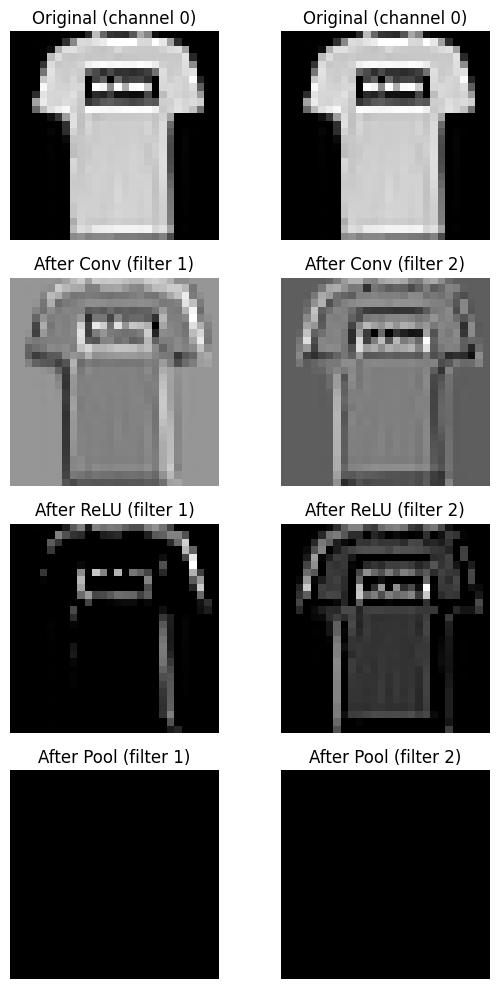

In [8]:
import matplotlib.pyplot as plt

# Select one sample (for instance, the first image in your batch)
sample = sample_batch[0]          # shape: (28, 28, 1)
conv_out = output[0]              # shape: (28, 28, 2)
relu_out = activation.output[0]   # shape: (28, 28, 2)
pool_out = pooling.output[0]      # shape: (14, 14, 2) because pooling halves H/W

# We'll plot both filters’ results side by side for clarity.
fig, axes = plt.subplots(4, 2, figsize=(6, 10))

# Stage 1: Original grayscale image
axes[0, 0].imshow(sample[..., 0], cmap='gray')
axes[0, 0].set_title("Original (channel 0)")
axes[0, 0].axis("off")

# Duplicate just to fill the second column for visual consistency
axes[0, 1].imshow(sample[..., 0], cmap='gray')
axes[0, 1].set_title("Original (channel 0)")
axes[0, 1].axis("off")

# Stage 2: After convolution
axes[1, 0].imshow(conv_out[..., 0], cmap='gray')
axes[1, 0].set_title("After Conv (filter 1)")
axes[1, 0].axis("off")
axes[1, 1].imshow(conv_out[..., 1], cmap='gray')
axes[1, 1].set_title("After Conv (filter 2)")
axes[1, 1].axis("off")

# Stage 3: After ReLU
axes[2, 0].imshow(relu_out[..., 0], cmap='gray')
axes[2, 0].set_title("After ReLU (filter 1)")
axes[2, 0].axis("off")
axes[2, 1].imshow(relu_out[..., 1], cmap='gray')
axes[2, 1].set_title("After ReLU (filter 2)")
axes[2, 1].axis("off")

# Stage 4: After Pooling
axes[3, 0].imshow(pool_out[..., 0], cmap='gray')
axes[3, 0].set_title("After Pool (filter 1)")
axes[3, 0].axis("off")
axes[3, 1].imshow(pool_out[..., 1], cmap='gray')
axes[3, 1].set_title("After Pool (filter 2)")
axes[3, 1].axis("off")

plt.tight_layout()
plt.show()
